<a href="https://colab.research.google.com/github/nikhitha2007/ML-SKILL/blob/main/09_Heart_Disease_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HEART DISEASE - RANDOM FOREST CLASSIFICATION

First five rows:
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  

Dataset shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

MODEL EVALUATION
Accuracy: 0.8033

Classification Report:
              preci

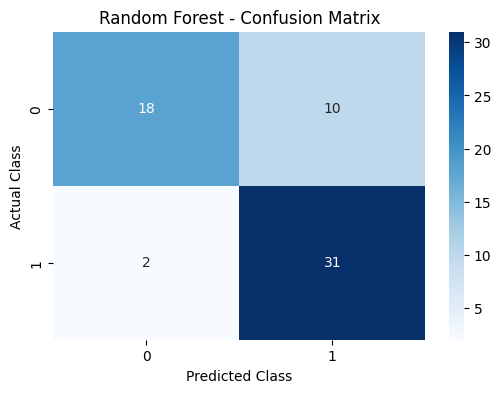


Top 10 Important Features:
cp          0.155390
thall       0.120316
thalachh    0.112750
oldpeak     0.107680
chol        0.086803
caa         0.086616
age         0.082952
trtbps      0.074618
exng        0.059074
slp         0.052692
dtype: float64


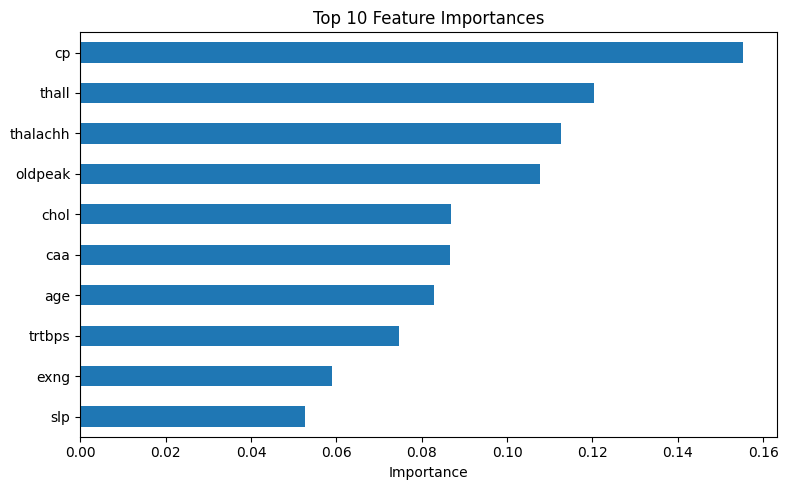


Predictions saved successfully!
PROGRAM 9 COMPLETED SUCCESSFULLY!


In [1]:

# PROGRAM 9: HEART DISEASE - RANDOM FOREST ENSEMBLE

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# 1. Load the dataset
url = "https://raw.githubusercontent.com/ramtinmt/heart-disease-classification/main/heart.csv"
df = pd.read_csv(url)

print("HEART DISEASE - RANDOM FOREST CLASSIFICATION")
print("=" * 55)

# 2. Explore the dataset
print("\nFirst five rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

# 3. Identify the target column
if "target" in df.columns:
    target_col = "target"
elif "output" in df.columns:
    target_col = "output"
elif "disease" in df.columns:
    target_col = "disease"
else:
    raise ValueError(
        "Target column not found. Columns: "
        + str(df.columns.tolist())
    )

df = df.dropna(subset=[target_col]).copy()

X = df.drop(columns=[target_col])
y = df[target_col]

# Convert categorical features into numeric columns
X = pd.get_dummies(X, drop_first=False)
X = X.replace([float("inf"), float("-inf")], float("nan"))

# 4. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Handle missing values using training-set medians
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

# 5. Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# 6. Train the model
model.fit(X_train, y_train)

# 7. Make predictions
y_pred = model.predict(X_test)

# 8. Evaluate the model
print("\nMODEL EVALUATION")
print("=" * 55)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

if len(model.classes_) == 2:
    y_prob = model.predict_proba(X_test)[:, 1]
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

# 9. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# 10. Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 11. Save predictions
results = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})

results.to_csv(
    "heart_disease_random_forest_predictions.csv",
    index=False
)

print("\nPredictions saved successfully!")
print("PROGRAM 9 COMPLETED SUCCESSFULLY!")